In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/sequences.csv")

df.head()

,sequence,label
0,ATGCGTATGCGATCGATCGATGCGTATGCGATCG,0
1,ATGCGTATGCGATCGATGCGTATGCGATCGATCG,0
2,GCGATGCGTATGCGATCGATGCGTATGCGATCG,0
3,ATGCGATCGATGCGTATGCGATCGATGCGTATG,0
4,GCGTATGCGATCGATGCGTATGCGATCGATGCG,0


In [6]:
df.shape

(20, 2)

In [2]:
import sys
sys.path.append("../src")

from kmer_utils import seq_to_kmers

In [7]:
seq = df["sequence"].iloc[0]

print("Sequence:", seq)
print("3-mers:", seq_to_kmers(seq, 3))

Sequence: ATGCGTATGCGATCGATCGATGCGTATGCGATCG
3-mers: ['ATG', 'TGC', 'GCG', 'CGT', 'GTA', 'TAT', 'ATG', 'TGC', 'GCG', 'CGA', 'GAT', 'ATC', 'TCG', 'CGA', 'GAT', 'ATC', 'TCG', 'CGA', 'GAT', 'ATG', 'TGC', 'GCG', 'CGT', 'GTA', 'TAT', 'ATG', 'TGC', 'GCG', 'CGA', 'GAT', 'ATC', 'TCG']


In [8]:
for k in [3, 4, 6]:
    kmers = seq_to_kmers(seq, k)
    print(f"k={k}: {len(kmers)} k-mers")
    print(kmers[:10])
    print()

k=3: 32 k-mers
['ATG', 'TGC', 'GCG', 'CGT', 'GTA', 'TAT', 'ATG', 'TGC', 'GCG', 'CGA']

k=4: 31 k-mers
['ATGC', 'TGCG', 'GCGT', 'CGTA', 'GTAT', 'TATG', 'ATGC', 'TGCG', 'GCGA', 'CGAT']

k=6: 29 k-mers
['ATGCGT', 'TGCGTA', 'GCGTAT', 'CGTATG', 'GTATGC', 'TATGCG', 'ATGCGA', 'TGCGAT', 'GCGATC', 'CGATCG']



In [9]:
from collections import Counter

for k in [3, 4, 6]:
    counts = Counter(seq_to_kmers(seq, k))
    print(f"\nk={k}")
    print(counts.most_common(5))


k=3
[('ATG', 4), ('TGC', 4), ('GCG', 4), ('CGA', 4), ('GAT', 4)]

k=4
[('ATGC', 4), ('TGCG', 4), ('CGAT', 4), ('GATC', 3), ('ATCG', 3)]

k=6
[('CGATCG', 3), ('ATGCGT', 2), ('TGCGTA', 2), ('GCGTAT', 2), ('CGTATG', 2)]


In [10]:
from represent import bag_of_words

X_bow, bow_vectorizer = bag_of_words(df, k=3)

print("Shape:", X_bow.shape)
print("Some k-mers:", bow_vectorizer.get_feature_names_out()[:10])

Shape: (20, 24)
Some k-mers: ['AAC' 'ACC' 'AGG' 'ATC' 'ATG' 'ATT' 'CCG' 'CCT' 'CGA' 'CGG']


In [11]:
from represent import tfidf

X_tfidf, tfidf_vectorizer = tfidf(df, k=3)

print("Shape:", X_tfidf.shape)
print("Some k-mers:", tfidf_vectorizer.get_feature_names_out()[:10])

Shape: (20, 24)
Some k-mers: ['AAC' 'ACC' 'AGG' 'ATC' 'ATG' 'ATT' 'CCG' 'CCT' 'CGA' 'CGG']


In [12]:
print("BoW:")
print(X_bow.toarray()[0][:10])

print("\nTF-IDF:")
print(X_tfidf.toarray()[0][:10])

BoW:
[0 0 0 3 4 0 0 0 4 0]

TF-IDF:
[0.         0.         0.         0.28937899 0.38583865 0.
 0.         0.         0.38583865 0.        ]


In [13]:
from represent import train_word2vec

w2v = train_word2vec(df, k=3)

print("Vocabulary size:", len(w2v.wv))

Vocabulary size: 24


In [14]:
from represent import sequence_embedding

embedding = sequence_embedding(df["sequence"].iloc[0], 3, w2v)

print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Embedding shape: (50,)
First 10 values: [ 0.0985087   0.0522948   0.11528175  0.01029949  0.08911507  0.14056656
 -0.23129918  0.08431597  0.05907415 -0.0453343 ]


Matplotlib is building the font cache; this may take a moment.


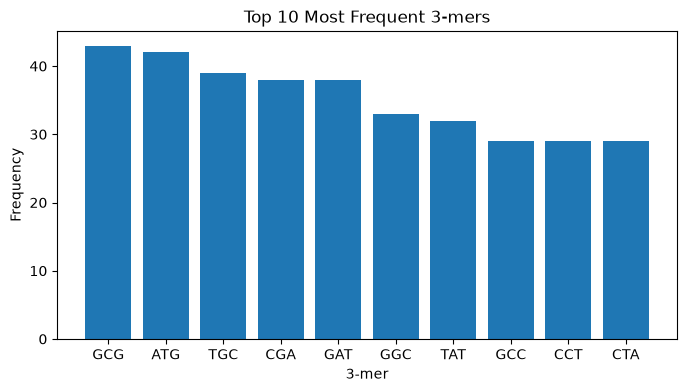

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter()

for s in df["sequence"]:
    counts.update(seq_to_kmers(s, 3))

top10 = counts.most_common(10)

words = [x[0] for x in top10]
frequencies = [x[1] for x in top10]

plt.figure(figsize=(8, 4))
plt.bar(words, frequencies)
plt.xlabel("3-mer")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent 3-mers")
plt.show()

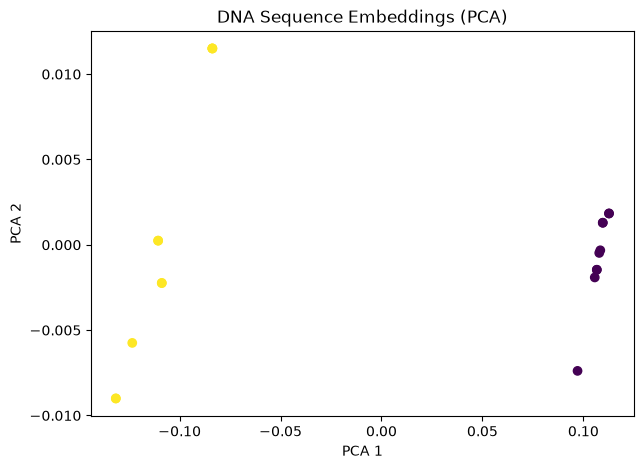

In [16]:
from sklearn.decomposition import PCA
from represent import embed_dataset

X_embed = embed_dataset(df, k=3, w2v_model=w2v)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_embed)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["label"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DNA Sequence Embeddings (PCA)")
plt.show()

In [18]:
from kmer_utils import dataset_vocab_stats

In [19]:
for k in [3, 4, 6]:
    stats = dataset_vocab_stats(df["sequence"].tolist(), k)
    print(stats)

{'k': 3, 'observed_vocab': 24, 'theoretical_vocab': 64, 'coverage_pct': 37.5, 'top_10': [('GCG', 43), ('ATG', 42), ('TGC', 39), ('CGA', 38), ('GAT', 38), ('GGC', 33), ('TAT', 32), ('GCC', 29), ('CCT', 29), ('CTA', 29)]}
{'k': 4, 'observed_vocab': 29, 'theoretical_vocab': 256, 'coverage_pct': 11.33, 'top_10': [('ATGC', 39), ('TGCG', 39), ('CGAT', 38), ('GGCC', 29), ('GCCT', 29), ('CCTA', 29), ('GCGA', 21), ('ATCG', 21), ('GCGT', 20), ('CGTA', 20)]}
{'k': 6, 'observed_vocab': 38, 'theoretical_vocab': 4096, 'coverage_pct': 0.93, 'top_10': [('GGCCTA', 29), ('GCGTAT', 20), ('CGATCG', 20), ('CGTATG', 19), ('ATGCGA', 19), ('TGCGAT', 19), ('ATGCGT', 18), ('TGCGTA', 18), ('GCGATC', 18), ('GTATGC', 17)]}


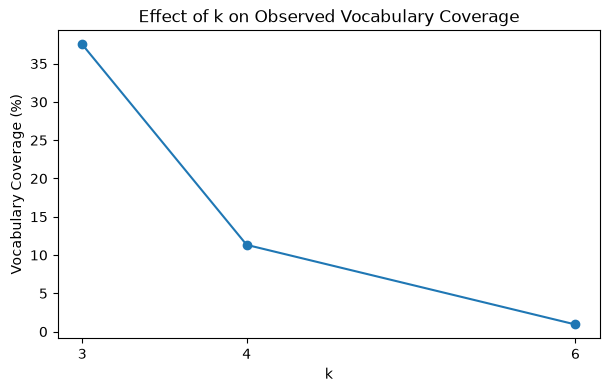

In [20]:
ks = [3, 4, 6]
coverage = [37.5, 11.33, 0.93]

plt.figure(figsize=(7, 4))
plt.plot(ks, coverage, marker="o")
plt.xlabel("k")
plt.ylabel("Vocabulary Coverage (%)")
plt.title("Effect of k on Observed Vocabulary Coverage")
plt.xticks(ks)
plt.show()